## 03 - Sequential Graph

In this notebook we'll do the following:
1. Create multiple nodes that **sequentially process** and update different parts of the graph state.
2. Connect the nodes together in a Graph
3. Invoke the graph (`graph.invoke()`) and see how the **state is transformed** step-by-step.

In [3]:
from typing import TypedDict, List, Any
from langgraph.graph import StateGraph, START, END

In [4]:
# Step 1: define the graph state
# define the state that will be passed around
# the graph - it should be an instance of TypedDict
class State(TypedDict):
    name: str
    age: str
    final: str

In [5]:
# Step 2: build the nodes (functions)
def first_node(state: State) -> dict[str, Any]:
    """this is the first node of our sequence"""
    return {"final": f"Hi {state["name"]}"}


def second_node(state: State) -> dict[str, Any]:
    """this is the second node of our sequence"""
    # append the age to the final message
    return {"final": f"{state["final"]}. You are {state["age"]} years old."}

In [7]:
# build out our graph
builder = StateGraph(State)
builder.add_node("first_node", first_node)
builder.add_node("second_node", second_node)
# add edges (define structure)
builder.add_edge(START, "first_node")
builder.add_edge("first_node", "second_node")
builder.add_edge("second_node", END)

graph = builder.compile()

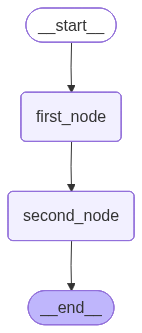

In [8]:
# and let's see how our
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [9]:
# now invoke the graph
# NOTE: the graph is a Runnable, so it has the invoke() function defined
from rich.console import Console

console = Console()

state = State(
    name="Bilbo Baggins",
    age="75",
)

response = graph.invoke(state)
# just to get a well-formatted dict displayed in output
console.print(response)
# you should get
# response["result"] == "Hi there Manish, the sum of integers is 190"

{'name': 'Bilbo Baggins', 'age': '75', 'final': 'Hi Bilbo Baggins. You are 75 years old.'}

### Exercise 
Your Task:
1. Accept a user's name, age and a list of skills
2. Pass the state through 3 nodes that:
    * **First Node:** personalizes the name field with a greeting
    * **Second Node:** describes the user's age
    * **Third Node:** Lists the users skills in a formatted string
3. Final output from the graph should be in the following format:

**Output:** "Linda, welcome to the system! You are 31 years old! You have skills in: Python, Machine Learning, and LangGraph"


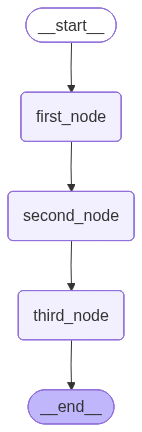

In [ ]:
# Step 1: define graph state
from typing import TypedDict, List, Any
from langgraph.graph import StateGraph, START, END
from typing import List


# Step1: define the graph state
class ExState(TypedDict):
    name: str
    age: str
    skills: List[str]
    result: str


# Step 2: define the node(s)
def first_node(state: ExState) -> dict[str, Any]:
    """this is the first node of our sequence"""
    return {"result": f"{state["name"]}, welcome to the system!"}


def second_node(state: ExState) -> dict[str, Any]:
    """this is the second node of our sequence"""
    # append the age to the final message
    return {"result": f"{state["result"]} You are {state["age"]} years old!"}


def third_node(state: ExState) -> dict[str, Any]:
    """this is the third node of our sequence"""
    # format the skills into a comma separated list
    if len(state["skills"]) > 1:
        # convert List["Python","ML", "LangGraph"] -> "Python, ML, and LangGraph"
        formatted_skills = (
            ", ".join(state["skills"][:-1]) + ", and " + state["skills"][-1]
        )
    else:
        formatted_skills = state["skills"][0] if state["skills"] else ""
    return {"result": f"{state["result"]} You have skills in: {formatted_skills}"}


# Step 3: build the graph
builder = StateGraph(ExState)
builder.add_node("first_node", first_node)
builder.add_node("second_node", second_node)
builder.add_node("third_node", third_node)
# add edges (define structure)
builder.add_edge(START, "first_node")
builder.add_edge("first_node", "second_node")
builder.add_edge("second_node", "third_node")
builder.add_edge("third_node", END)

graph = builder.compile()

# and let's see how our graph looks
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [13]:
# Step 4: invoke the graph

from rich.console import Console

console = Console()
state = ExState(
    name="Linda", age="31", skills=["Python", "Machine Learning", "LangGraph"]
)
response = graph.invoke(state)
console.print(f"Invoking graph with {state}")
console.print(response)

Invoking graph with {'name': 'Linda', 'age': '31', 'skills': ['Python', 'Machine Learning', 'LangGraph']}

{
    'name': 'Linda',
    'age': '31',
    'skills': ['Python', 'Machine Learning', 'LangGraph'],
    'result': 'Linda, welcome to the system! You are 31 years old! You have skills in: Python, Machine Learning, 
and LangGraph'
}